<a href="https://colab.research.google.com/github/baanujan-18/PLC---Automation/blob/main/Colab/process_flowchart_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

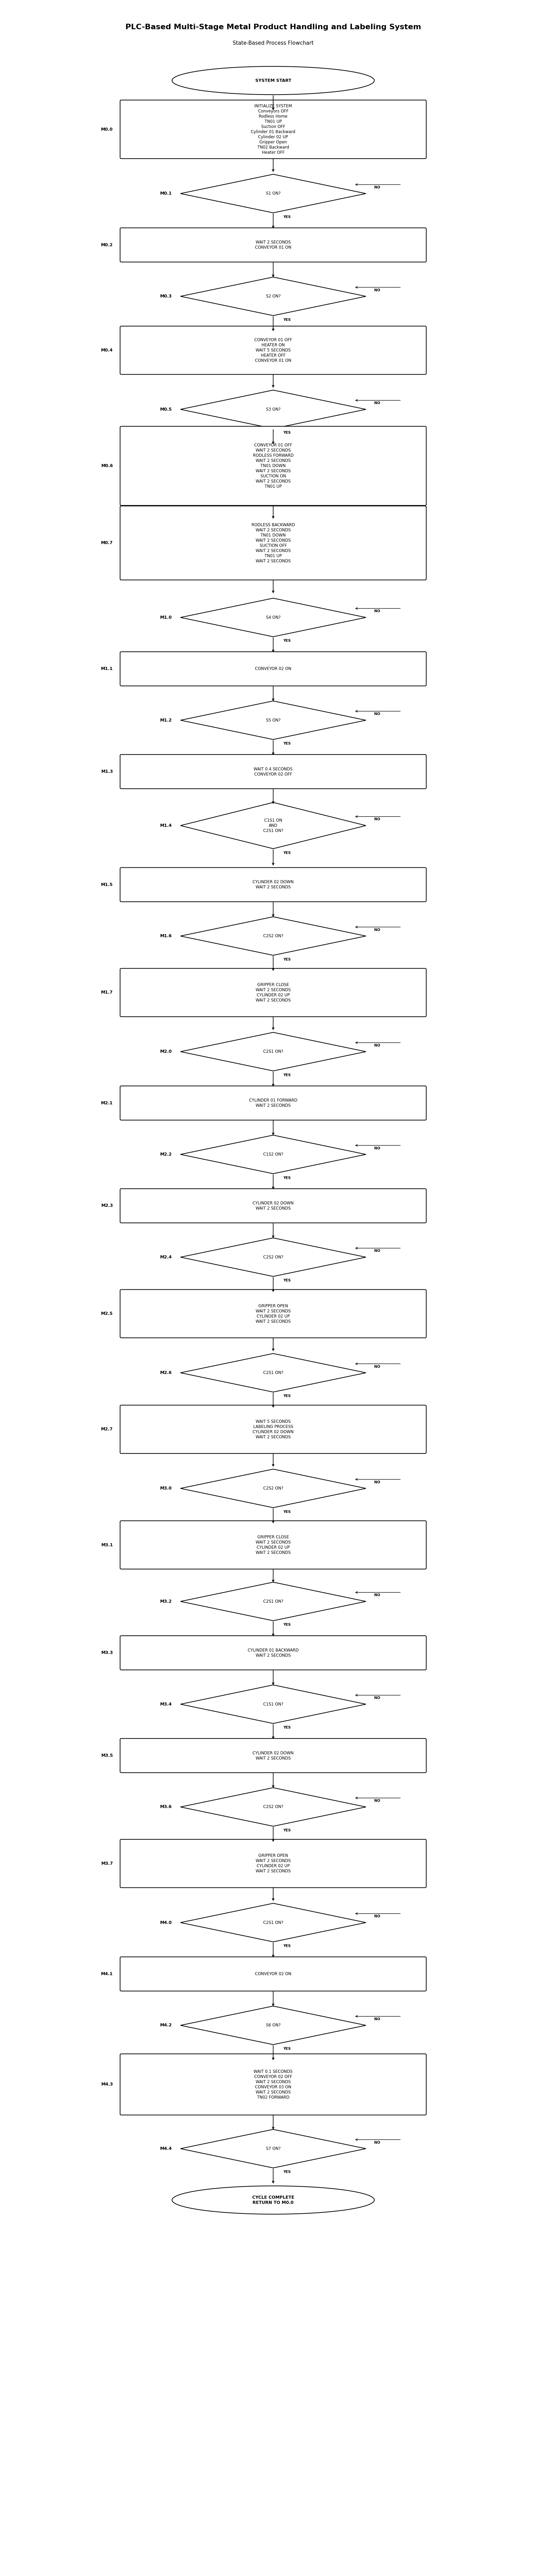

Created:
multi_stage_process_flowchart.png
multi_stage_process_flowchart.pdf


In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Polygon, Ellipse

# ============================================================
# PLC-BASED MULTI-STAGE METAL PRODUCT HANDLING
# AND LABELING SYSTEM
#
# FLOWCHART BASED ON THE ORIGINAL HAND-DRAWN FLOWCHART
# AND THE SIEMENS S7-200 LADDER PROGRAM
# ============================================================

BLACK = "black"

fig, ax = plt.subplots(figsize=(16, 75))

ax.set_xlim(0, 16)
ax.set_ylim(0, 100)
ax.axis("off")

CENTER_X = 8


# ============================================================
# DRAWING FUNCTIONS
# ============================================================

def process_box(x, y, text, state=None, width=9, height=1.25):
    """
    Draw a normal process/action block.
    """

    box = FancyBboxPatch(
        (x - width/2, y - height/2),
        width,
        height,
        boxstyle="round,pad=0.04",
        linewidth=1.5,
        edgecolor=BLACK,
        facecolor="white"
    )

    ax.add_patch(box)

    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=8.5,
        color=BLACK
    )

    if state:
        ax.text(
            x - width/2 - 0.25,
            y,
            state,
            ha="right",
            va="center",
            fontsize=9,
            fontweight="bold",
            color=BLACK
        )


def decision_box(x, y, text, state=None, width=5.5, height=1.5):
    """
    Draw a decision diamond.
    """

    points = [
        (x, y + height/2),
        (x + width/2, y),
        (x, y - height/2),
        (x - width/2, y)
    ]

    diamond = Polygon(
        points,
        closed=True,
        linewidth=1.5,
        edgecolor=BLACK,
        facecolor="white"
    )

    ax.add_patch(diamond)

    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=8.5,
        color=BLACK
    )

    if state:
        ax.text(
            x - width/2 - 0.25,
            y,
            state,
            ha="right",
            va="center",
            fontsize=9,
            fontweight="bold",
            color=BLACK
        )


def start_end(x, y, text, width=6, height=1.1):
    """
    Draw start/end ellipse.
    """

    e = Ellipse(
        (x, y),
        width,
        height,
        fill=False,
        linewidth=1.5,
        edgecolor=BLACK
    )

    ax.add_patch(e)

    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold"
    )


def arrow(x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.3,
            color=BLACK
        )
    )


def down_arrow(y1, y2):
    arrow(
        CENTER_X,
        y1,
        CENTER_X,
        y2
    )


def yes_text(y):
    ax.text(
        CENTER_X + 0.30,
        y,
        "YES",
        fontsize=7.5,
        fontweight="bold"
    )


def no_loop(y, text="NO"):
    """
    Add a simple NO indication beside a decision.
    """

    ax.text(
        CENTER_X + 3.0,
        y + 0.2,
        text,
        fontsize=7.5,
        fontweight="bold"
    )

    ax.annotate(
        "",
        xy=(CENTER_X + 2.4, y + 0.35),
        xytext=(CENTER_X + 3.8, y + 0.35),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1,
            color=BLACK
        )
    )


# ============================================================
# TITLE
# ============================================================

ax.text(
    CENTER_X,
    99,
    "PLC-Based Multi-Stage Metal Product Handling and Labeling System",
    ha="center",
    fontsize=16,
    fontweight="bold"
)

ax.text(
    CENTER_X,
    98.4,
    "State-Based Process Flowchart",
    ha="center",
    fontsize=11
)


# ============================================================
# START / INITIALIZATION
# ============================================================

y = 97.0

start_end(
    CENTER_X,
    y,
    "SYSTEM START"
)

down_arrow(y - 0.55, y - 1.2)

y -= 1.9

process_box(
    CENTER_X,
    y,
    "INITIALIZE SYSTEM\n"
    "Conveyors OFF\n"
    "Rodless Home\n"
    "TN01 UP\n"
    "Suction OFF\n"
    "Cylinder 01 Backward\n"
    "Cylinder 02 UP\n"
    "Gripper Open\n"
    "TN02 Backward\n"
    "Heater OFF",
    state="M0.0",
    height=2.2
)

down_arrow(y - 1.1, y - 1.7)


# ============================================================
# S1
# ============================================================

y -= 2.5

decision_box(
    CENTER_X,
    y,
    "S1 ON?",
    state="M0.1"
)

yes_text(y - 0.95)
no_loop(y)

down_arrow(y - 0.75, y - 1.4)

y -= 2.0

process_box(
    CENTER_X,
    y,
    "WAIT 2 SECONDS\nCONVEYOR 01 ON",
    state="M0.2"
)

down_arrow(y - 0.65, y - 1.3)


# ============================================================
# S2
# ============================================================

y -= 2.0

decision_box(
    CENTER_X,
    y,
    "S2 ON?",
    state="M0.3"
)

yes_text(y - 0.95)
no_loop(y)

down_arrow(y - 0.75, y - 1.4)

y -= 2.1

process_box(
    CENTER_X,
    y,
    "CONVEYOR 01 OFF\n"
    "HEATER ON\n"
    "WAIT 5 SECONDS\n"
    "HEATER OFF\n"
    "CONVEYOR 01 ON",
    state="M0.4",
    height=1.8
)

down_arrow(y - 0.9, y - 1.5)


# ============================================================
# S3
# ============================================================

y -= 2.3

decision_box(
    CENTER_X,
    y,
    "S3 ON?",
    state="M0.5"
)

yes_text(y - 0.95)
no_loop(y)

down_arrow(y - 0.75, y - 1.4)

y -= 2.2

process_box(
    CENTER_X,
    y,
    "CONVEYOR 01 OFF\n"
    "WAIT 2 SECONDS\n"
    "RODLESS FORWARD\n"
    "WAIT 2 SECONDS\n"
    "TN01 DOWN\n"
    "WAIT 2 SECONDS\n"
    "SUCTION ON\n"
    "WAIT 2 SECONDS\n"
    "TN01 UP",
    state="M0.6",
    height=3.0
)

down_arrow(y - 1.5, y - 2.1)

y -= 3.0

process_box(
    CENTER_X,
    y,
    "RODLESS BACKWARD\n"
    "WAIT 2 SECONDS\n"
    "TN01 DOWN\n"
    "WAIT 2 SECONDS\n"
    "SUCTION OFF\n"
    "WAIT 2 SECONDS\n"
    "TN01 UP\n"
    "WAIT 2 SECONDS",
    state="M0.7",
    height=2.8
)

down_arrow(y - 1.4, y - 2.0)


# ============================================================
# S4
# ============================================================

y -= 2.9

decision_box(
    CENTER_X,
    y,
    "S4 ON?",
    state="M1.0"
)

yes_text(y - 0.95)
no_loop(y)

down_arrow(y - 0.75, y - 1.4)

y -= 2.0

process_box(
    CENTER_X,
    y,
    "CONVEYOR 02 ON",
    state="M1.1"
)

down_arrow(y - 0.65, y - 1.3)


# ============================================================
# S5
# ============================================================

y -= 2.0

decision_box(
    CENTER_X,
    y,
    "S5 ON?",
    state="M1.2"
)

yes_text(y - 0.95)
no_loop(y)

down_arrow(y - 0.75, y - 1.4)

y -= 2.0

process_box(
    CENTER_X,
    y,
    "WAIT 0.4 SECONDS\nCONVEYOR 02 OFF",
    state="M1.3"
)

down_arrow(y - 0.65, y - 1.3)


# ============================================================
# HOME POSITION CONFIRMATION
# ============================================================

y -= 2.1

decision_box(
    CENTER_X,
    y,
    "C1S1 ON\nAND\nC2S1 ON?",
    state="M1.4",
    height=1.8
)

yes_text(y - 1.1)
no_loop(y)

down_arrow(y - 0.9, y - 1.6)

y -= 2.3

process_box(
    CENTER_X,
    y,
    "CYLINDER 02 DOWN\nWAIT 2 SECONDS",
    state="M1.5"
)

down_arrow(y - 0.65, y - 1.3)

y -= 2.0

decision_box(
    CENTER_X,
    y,
    "C2S2 ON?",
    state="M1.6"
)

yes_text(y - 0.95)
no_loop(y)

down_arrow(y - 0.75, y - 1.4)


# ============================================================
# PICK PRODUCT
# ============================================================

y -= 2.2

process_box(
    CENTER_X,
    y,
    "GRIPPER CLOSE\n"
    "WAIT 2 SECONDS\n"
    "CYLINDER 02 UP\n"
    "WAIT 2 SECONDS",
    state="M1.7",
    height=1.8
)

down_arrow(y - 0.9, y - 1.5)

y -= 2.3

decision_box(
    CENTER_X,
    y,
    "C2S1 ON?",
    state="M2.0"
)

yes_text(y - 0.95)
no_loop(y)

down_arrow(y - 0.75, y - 1.4)

y -= 2.0

process_box(
    CENTER_X,
    y,
    "CYLINDER 01 FORWARD\nWAIT 2 SECONDS",
    state="M2.1"
)

down_arrow(y - 0.65, y - 1.3)

y -= 2.0

decision_box(
    CENTER_X,
    y,
    "C1S2 ON?",
    state="M2.2"
)

yes_text(y - 0.95)
no_loop(y)

down_arrow(y - 0.75, y - 1.4)

y -= 2.0

process_box(
    CENTER_X,
    y,
    "CYLINDER 02 DOWN\nWAIT 2 SECONDS",
    state="M2.3"
)

down_arrow(y - 0.65, y - 1.3)

y -= 2.0

decision_box(
    CENTER_X,
    y,
    "C2S2 ON?",
    state="M2.4"
)

yes_text(y - 0.95)
no_loop(y)

down_arrow(y - 0.75, y - 1.4)


# ============================================================
# PLACE AT LABELING POSITION
# ============================================================

y -= 2.2

process_box(
    CENTER_X,
    y,
    "GRIPPER OPEN\n"
    "WAIT 2 SECONDS\n"
    "CYLINDER 02 UP\n"
    "WAIT 2 SECONDS",
    state="M2.5",
    height=1.8
)

down_arrow(y - 0.9, y - 1.5)

y -= 2.3

decision_box(
    CENTER_X,
    y,
    "C2S1 ON?",
    state="M2.6"
)

yes_text(y - 0.95)
no_loop(y)

down_arrow(y - 0.75, y - 1.4)

y -= 2.2

process_box(
    CENTER_X,
    y,
    "WAIT 5 SECONDS\nLABELING PROCESS\n"
    "CYLINDER 02 DOWN\n"
    "WAIT 2 SECONDS",
    state="M2.7",
    height=1.8
)

down_arrow(y - 0.9, y - 1.5)


# ============================================================
# PICK PRODUCT AFTER LABELING
# ============================================================

y -= 2.3

decision_box(
    CENTER_X,
    y,
    "C2S2 ON?",
    state="M3.0"
)

yes_text(y - 0.95)
no_loop(y)

down_arrow(y - 0.75, y - 1.4)

y -= 2.2

process_box(
    CENTER_X,
    y,
    "GRIPPER CLOSE\n"
    "WAIT 2 SECONDS\n"
    "CYLINDER 02 UP\n"
    "WAIT 2 SECONDS",
    state="M3.1",
    height=1.8
)

down_arrow(y - 0.9, y - 1.5)

y -= 2.2

decision_box(
    CENTER_X,
    y,
    "C2S1 ON?",
    state="M3.2"
)

yes_text(y - 0.95)
no_loop(y)

down_arrow(y - 0.75, y - 1.4)

y -= 2.0

process_box(
    CENTER_X,
    y,
    "CYLINDER 01 BACKWARD\nWAIT 2 SECONDS",
    state="M3.3"
)

down_arrow(y - 0.65, y - 1.3)

y -= 2.0

decision_box(
    CENTER_X,
    y,
    "C1S1 ON?",
    state="M3.4"
)

yes_text(y - 0.95)
no_loop(y)

down_arrow(y - 0.75, y - 1.4)

y -= 2.0

process_box(
    CENTER_X,
    y,
    "CYLINDER 02 DOWN\nWAIT 2 SECONDS",
    state="M3.5"
)

down_arrow(y - 0.65, y - 1.3)

y -= 2.0

decision_box(
    CENTER_X,
    y,
    "C2S2 ON?",
    state="M3.6"
)

yes_text(y - 0.95)
no_loop(y)

down_arrow(y - 0.75, y - 1.4)


# ============================================================
# RETURN PRODUCT TO CONVEYOR 2
# ============================================================

y -= 2.2

process_box(
    CENTER_X,
    y,
    "GRIPPER OPEN\n"
    "WAIT 2 SECONDS\n"
    "CYLINDER 02 UP\n"
    "WAIT 2 SECONDS",
    state="M3.7",
    height=1.8
)

down_arrow(y - 0.9, y - 1.5)

y -= 2.3

decision_box(
    CENTER_X,
    y,
    "C2S1 ON?",
    state="M4.0"
)

yes_text(y - 0.95)
no_loop(y)

down_arrow(y - 0.75, y - 1.4)

y -= 2.0

process_box(
    CENTER_X,
    y,
    "CONVEYOR 02 ON",
    state="M4.1"
)

down_arrow(y - 0.65, y - 1.3)


# ============================================================
# S6
# ============================================================

y -= 2.0

decision_box(
    CENTER_X,
    y,
    "S6 ON?",
    state="M4.2"
)

yes_text(y - 0.95)
no_loop(y)

down_arrow(y - 0.75, y - 1.4)

y -= 2.3

process_box(
    CENTER_X,
    y,
    "WAIT 0.1 SECONDS\n"
    "CONVEYOR 02 OFF\n"
    "WAIT 2 SECONDS\n"
    "CONVEYOR 03 ON\n"
    "WAIT 2 SECONDS\n"
    "TN02 FORWARD",
    state="M4.3",
    height=2.3
)

down_arrow(y - 1.15, y - 1.8)


# ============================================================
# S7
# ============================================================

y -= 2.5

decision_box(
    CENTER_X,
    y,
    "S7 ON?",
    state="M4.4"
)

yes_text(y - 0.95)
no_loop(y)

down_arrow(y - 0.75, y - 1.4)

y -= 2.0

start_end(
    CENTER_X,
    y,
    "CYCLE COMPLETE\nRETURN TO M0.0"
)


# ============================================================
# EXPORT
# ============================================================

plt.tight_layout()

plt.savefig(
    "multi_stage_process_flowchart.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    "multi_stage_process_flowchart.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Created:")
print("multi_stage_process_flowchart.png")
print("multi_stage_process_flowchart.pdf")

In [3]:
from google.colab import files

files.download("multi_stage_process_flowchart.png")
files.download("multi_stage_process_flowchart.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
from google.colab import files

files.download("multi_stage_process_flowchart.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# ============================================================
# INSTALL GRAPHVIZ
# ============================================================

!apt-get -qq install graphviz
!pip -q install graphviz


# ============================================================
# IMPORT
# ============================================================

from graphviz import Digraph


# ============================================================
# CREATE FLOWCHART
# ============================================================

dot = Digraph(
    "multi_stage_metal_handling_flowchart",
    format="png"
)

dot.attr(
    rankdir="TB",
    bgcolor="white",
    splines="ortho",
    nodesep="0.35",
    ranksep="0.50",
    pad="0.3"
)

dot.attr(
    label=(
        "PLC-Based Multi-Stage Metal Product Handling "
        "and Labeling System\n"
        "State-Based Process Flowchart"
    ),
    labelloc="t",
    fontsize="20",
    fontname="Arial"
)


# ============================================================
# NODE STYLES
# ============================================================

PROCESS_STYLE = {
    "shape": "box",
    "style": "rounded",
    "fontname": "Arial",
    "fontsize": "10",
    "margin": "0.15"
}

DECISION_STYLE = {
    "shape": "diamond",
    "fontname": "Arial",
    "fontsize": "10",
    "margin": "0.08"
}

START_END_STYLE = {
    "shape": "oval",
    "fontname": "Arial",
    "fontsize": "11",
    "margin": "0.15"
}


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def process(node_id, state, text):
    """
    Create a process/action node.
    """

    dot.node(
        node_id,
        label=f"{state}\n{text}",
        **PROCESS_STYLE
    )


def decision(node_id, state, text):
    """
    Create a decision node.
    """

    dot.node(
        node_id,
        label=f"{state}\n{text}",
        **DECISION_STYLE
    )


def normal(src, dst):
    """
    Normal connection between process states.
    """

    dot.edge(
        src,
        dst,
        arrowhead="normal"
    )


def yes(src, dst):
    """
    YES condition advances to next state.
    xlabel is used because splines='ortho'.
    """

    dot.edge(
        src,
        dst,
        xlabel="YES",
        fontsize="9",
        fontname="Arial",
        arrowhead="normal"
    )


def wait_here(node_id):
    """
    NO condition stays at the SAME decision.

    It does not go backward to a previous state.
    """

    dot.edge(
        node_id,
        node_id,
        xlabel="NO",
        fontsize="9",
        fontname="Arial",
        constraint="false",
        arrowhead="normal"
    )


# ============================================================
# START
# ============================================================

dot.node(
    "START",
    label="START",
    **START_END_STYLE
)


# ============================================================
# M0.0 - INITIALIZATION
# ============================================================

process(
    "M00",
    "M0.0",
    """INITIALIZE SYSTEM

Conveyors OFF
Rodless Home
TN01 UP
Suction OFF
Cylinder 01 Backward
Cylinder 02 UP
Gripper Open
TN02 Backward
Heater OFF"""
)

normal("START", "M00")


# ============================================================
# M0.1 - S1
# ============================================================

decision(
    "M01",
    "M0.1",
    """S1 ON?

Product detected
at Conveyor 1"""
)

normal("M00", "M01")

wait_here("M01")


# ============================================================
# M0.2 - START CONVEYOR 1
# ============================================================

process(
    "M02",
    "M0.2",
    """WAIT 2 SECONDS

CONVEYOR 01 ON"""
)

yes("M01", "M02")


# ============================================================
# M0.3 - S2
# ============================================================

decision(
    "M03",
    "M0.3",
    """S2 ON?

Heating position
detected"""
)

normal("M02", "M03")

wait_here("M03")


# ============================================================
# M0.4 - HEATING
# ============================================================

process(
    "M04",
    "M0.4",
    """CONVEYOR 01 OFF

HEATER ON

WAIT 5 SECONDS

HEATER OFF

CONVEYOR 01 ON"""
)

yes("M03", "M04")


# ============================================================
# M0.5 - S3
# ============================================================

decision(
    "M05",
    "M0.5",
    """S3 ON?

Suction-transfer
position detected"""
)

normal("M04", "M05")

wait_here("M05")


# ============================================================
# M0.6 - FIRST SUCTION TRANSFER SEQUENCE
# ============================================================

process(
    "M06",
    "M0.6",
    """CONVEYOR 01 OFF

WAIT 2 SECONDS

RODLESS FORWARD

WAIT 2 SECONDS

TN01 DOWN

WAIT 2 SECONDS

SUCTION ON

WAIT 2 SECONDS

TN01 UP"""
)

yes("M05", "M06")


# ============================================================
# M0.7 - COMPLETE TRANSFER TO CONVEYOR 2
# ============================================================

process(
    "M07",
    "M0.7",
    """RODLESS BACKWARD

WAIT 2 SECONDS

TN01 DOWN

WAIT 2 SECONDS

SUCTION OFF

WAIT 2 SECONDS

TN01 UP

WAIT 2 SECONDS"""
)

normal("M06", "M07")


# ============================================================
# M1.0 - S4
# ============================================================

decision(
    "M10",
    "M1.0",
    """S4 ON?

Product received
on Conveyor 2"""
)

normal("M07", "M10")

wait_here("M10")


# ============================================================
# M1.1 - CONVEYOR 2
# ============================================================

process(
    "M11",
    "M1.1",
    """CONVEYOR 02 ON"""
)

yes("M10", "M11")


# ============================================================
# M1.2 - S5
# ============================================================

decision(
    "M12",
    "M1.2",
    """S5 ON?

Product detected at
pick-and-place station"""
)

normal("M11", "M12")

wait_here("M12")


# ============================================================
# M1.3 - POSITION PRODUCT
# ============================================================

process(
    "M13",
    "M1.3",
    """WAIT 0.4 SECONDS

CONVEYOR 02 OFF"""
)

yes("M12", "M13")


# ============================================================
# M1.4 - CHECK HOME POSITIONS
# ============================================================

decision(
    "M14",
    "M1.4",
    """C1S1 ON
AND
C2S1 ON?

Cylinder 01 Home
Cylinder 02 Up"""
)

normal("M13", "M14")

wait_here("M14")


# ============================================================
# M1.5 - CYLINDER 2 DOWN
# ============================================================

process(
    "M15",
    "M1.5",
    """CYLINDER 02 DOWN

WAIT 2 SECONDS"""
)

yes("M14", "M15")


# ============================================================
# M1.6 - CHECK C2S2
# ============================================================

decision(
    "M16",
    "M1.6",
    """C2S2 ON?

Cylinder 02
Lower Position"""
)

normal("M15", "M16")

wait_here("M16")


# ============================================================
# M1.7 - GRIP PRODUCT AND LIFT
# ============================================================

process(
    "M17",
    "M1.7",
    """GRIPPER CLOSE

WAIT 2 SECONDS

CYLINDER 02 UP

WAIT 2 SECONDS"""
)

yes("M16", "M17")


# ============================================================
# M2.0 - CHECK C2S1
# ============================================================

decision(
    "M20",
    "M2.0",
    """C2S1 ON?

Cylinder 02
Upper Position"""
)

normal("M17", "M20")

wait_here("M20")


# ============================================================
# M2.1 - CYLINDER 1 FORWARD
# ============================================================

process(
    "M21",
    "M2.1",
    """CYLINDER 01 FORWARD

WAIT 2 SECONDS"""
)

yes("M20", "M21")


# ============================================================
# M2.2 - CHECK C1S2
# ============================================================

decision(
    "M22",
    "M2.2",
    """C1S2 ON?

Cylinder 01
Forward Position"""
)

normal("M21", "M22")

wait_here("M22")


# ============================================================
# M2.3 - CYLINDER 2 DOWN AT LABELING POSITION
# ============================================================

process(
    "M23",
    "M2.3",
    """CYLINDER 02 DOWN

WAIT 2 SECONDS"""
)

yes("M22", "M23")


# ============================================================
# M2.4 - CHECK LOWER POSITION
# ============================================================

decision(
    "M24",
    "M2.4",
    """C2S2 ON?

Cylinder 02
Lower Position"""
)

normal("M23", "M24")

wait_here("M24")


# ============================================================
# M2.5 - RELEASE PRODUCT AT LABELING POSITION
# ============================================================

process(
    "M25",
    "M2.5",
    """GRIPPER OPEN

WAIT 2 SECONDS

CYLINDER 02 UP

WAIT 2 SECONDS"""
)

yes("M24", "M25")


# ============================================================
# M2.6 - CHECK UPPER POSITION
# ============================================================

decision(
    "M26",
    "M2.6",
    """C2S1 ON?

Cylinder 02
Upper Position"""
)

normal("M25", "M26")

wait_here("M26")


# ============================================================
# M2.7 - LABELING + MOVE DOWN
# ============================================================

process(
    "M27",
    "M2.7",
    """WAIT 5 SECONDS

LABELING PROCESS

CYLINDER 02 DOWN

WAIT 2 SECONDS"""
)

yes("M26", "M27")


# ============================================================
# M3.0 - CHECK C2S2
# ============================================================

decision(
    "M30",
    "M3.0",
    """C2S2 ON?

Cylinder 02
Lower Position"""
)

normal("M27", "M30")

wait_here("M30")


# ============================================================
# M3.1 - PICK LABELED PRODUCT
# ============================================================

process(
    "M31",
    "M3.1",
    """GRIPPER CLOSE

WAIT 2 SECONDS

CYLINDER 02 UP

WAIT 2 SECONDS"""
)

yes("M30", "M31")


# ============================================================
# M3.2 - CHECK UP POSITION
# ============================================================

decision(
    "M32",
    "M3.2",
    """C2S1 ON?

Cylinder 02
Upper Position"""
)

normal("M31", "M32")

wait_here("M32")


# ============================================================
# M3.3 - CYLINDER 1 BACKWARD
# ============================================================

process(
    "M33",
    "M3.3",
    """CYLINDER 01 BACKWARD

WAIT 2 SECONDS"""
)

yes("M32", "M33")


# ============================================================
# M3.4 - CHECK C1S1
# ============================================================

decision(
    "M34",
    "M3.4",
    """C1S1 ON?

Cylinder 01
Home Position"""
)

normal("M33", "M34")

wait_here("M34")


# ============================================================
# M3.5 - CYLINDER 2 DOWN
# ============================================================

process(
    "M35",
    "M3.5",
    """CYLINDER 02 DOWN

WAIT 2 SECONDS"""
)

yes("M34", "M35")


# ============================================================
# M3.6 - CHECK C2S2
# ============================================================

decision(
    "M36",
    "M3.6",
    """C2S2 ON?

Cylinder 02
Lower Position"""
)

normal("M35", "M36")

wait_here("M36")


# ============================================================
# M3.7 - RELEASE PRODUCT BACK TO CONVEYOR 2
# ============================================================

process(
    "M37",
    "M3.7",
    """GRIPPER OPEN

WAIT 2 SECONDS

CYLINDER 02 UP

WAIT 2 SECONDS"""
)

yes("M36", "M37")


# ============================================================
# M4.0 - CHECK C2S1
# ============================================================

decision(
    "M40",
    "M4.0",
    """C2S1 ON?

Cylinder 02
Upper Position"""
)

normal("M37", "M40")

wait_here("M40")


# ============================================================
# M4.1 - START CONVEYOR 2 AGAIN
# ============================================================

process(
    "M41",
    "M4.1",
    """CONVEYOR 02 ON"""
)

yes("M40", "M41")


# ============================================================
# M4.2 - S6
# ============================================================

decision(
    "M42",
    "M4.2",
    """S6 ON?

Final transfer
position detected"""
)

normal("M41", "M42")

wait_here("M42")


# ============================================================
# M4.3 - FINAL TRANSFER
# ============================================================

process(
    "M43",
    "M4.3",
    """WAIT 0.1 SECONDS

CONVEYOR 02 OFF

WAIT 2 SECONDS

CONVEYOR 03 ON

WAIT 2 SECONDS

TN02 FORWARD"""
)

yes("M42", "M43")


# ============================================================
# M4.4 - S7
# ============================================================

decision(
    "M44",
    "M4.4",
    """S7 ON?

Final product
detected"""
)

normal("M43", "M44")

# If S7 is not ON, remain here.
wait_here("M44")


# ============================================================
# ONLY M4.4 YES RETURNS TO M0.0
# ============================================================

dot.edge(
    "M44",
    "M00",
    xlabel="YES - NEXT CYCLE",
    fontsize="9",
    fontname="Arial",
    constraint="false",
    arrowhead="normal"
)


# ============================================================
# GENERATE PNG
# ============================================================

dot.format = "png"

dot.render(
    "multi_stage_flowchart_final",
    cleanup=True
)


# ============================================================
# GENERATE PDF
# ============================================================

dot.format = "pdf"

dot.render(
    "multi_stage_flowchart_final",
    cleanup=True
)


# ============================================================
# FINISHED
# ============================================================

print("Flowchart created successfully.")
print()
print("Created files:")
print("multi_stage_flowchart_final.png")
print("multi_stage_flowchart_final.pdf")

Flowchart created successfully.

Created files:
multi_stage_flowchart_final.png
multi_stage_flowchart_final.pdf


In [10]:
from google.colab import files

files.download("multi_stage_flowchart_final.png")
files.download("multi_stage_flowchart_final.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

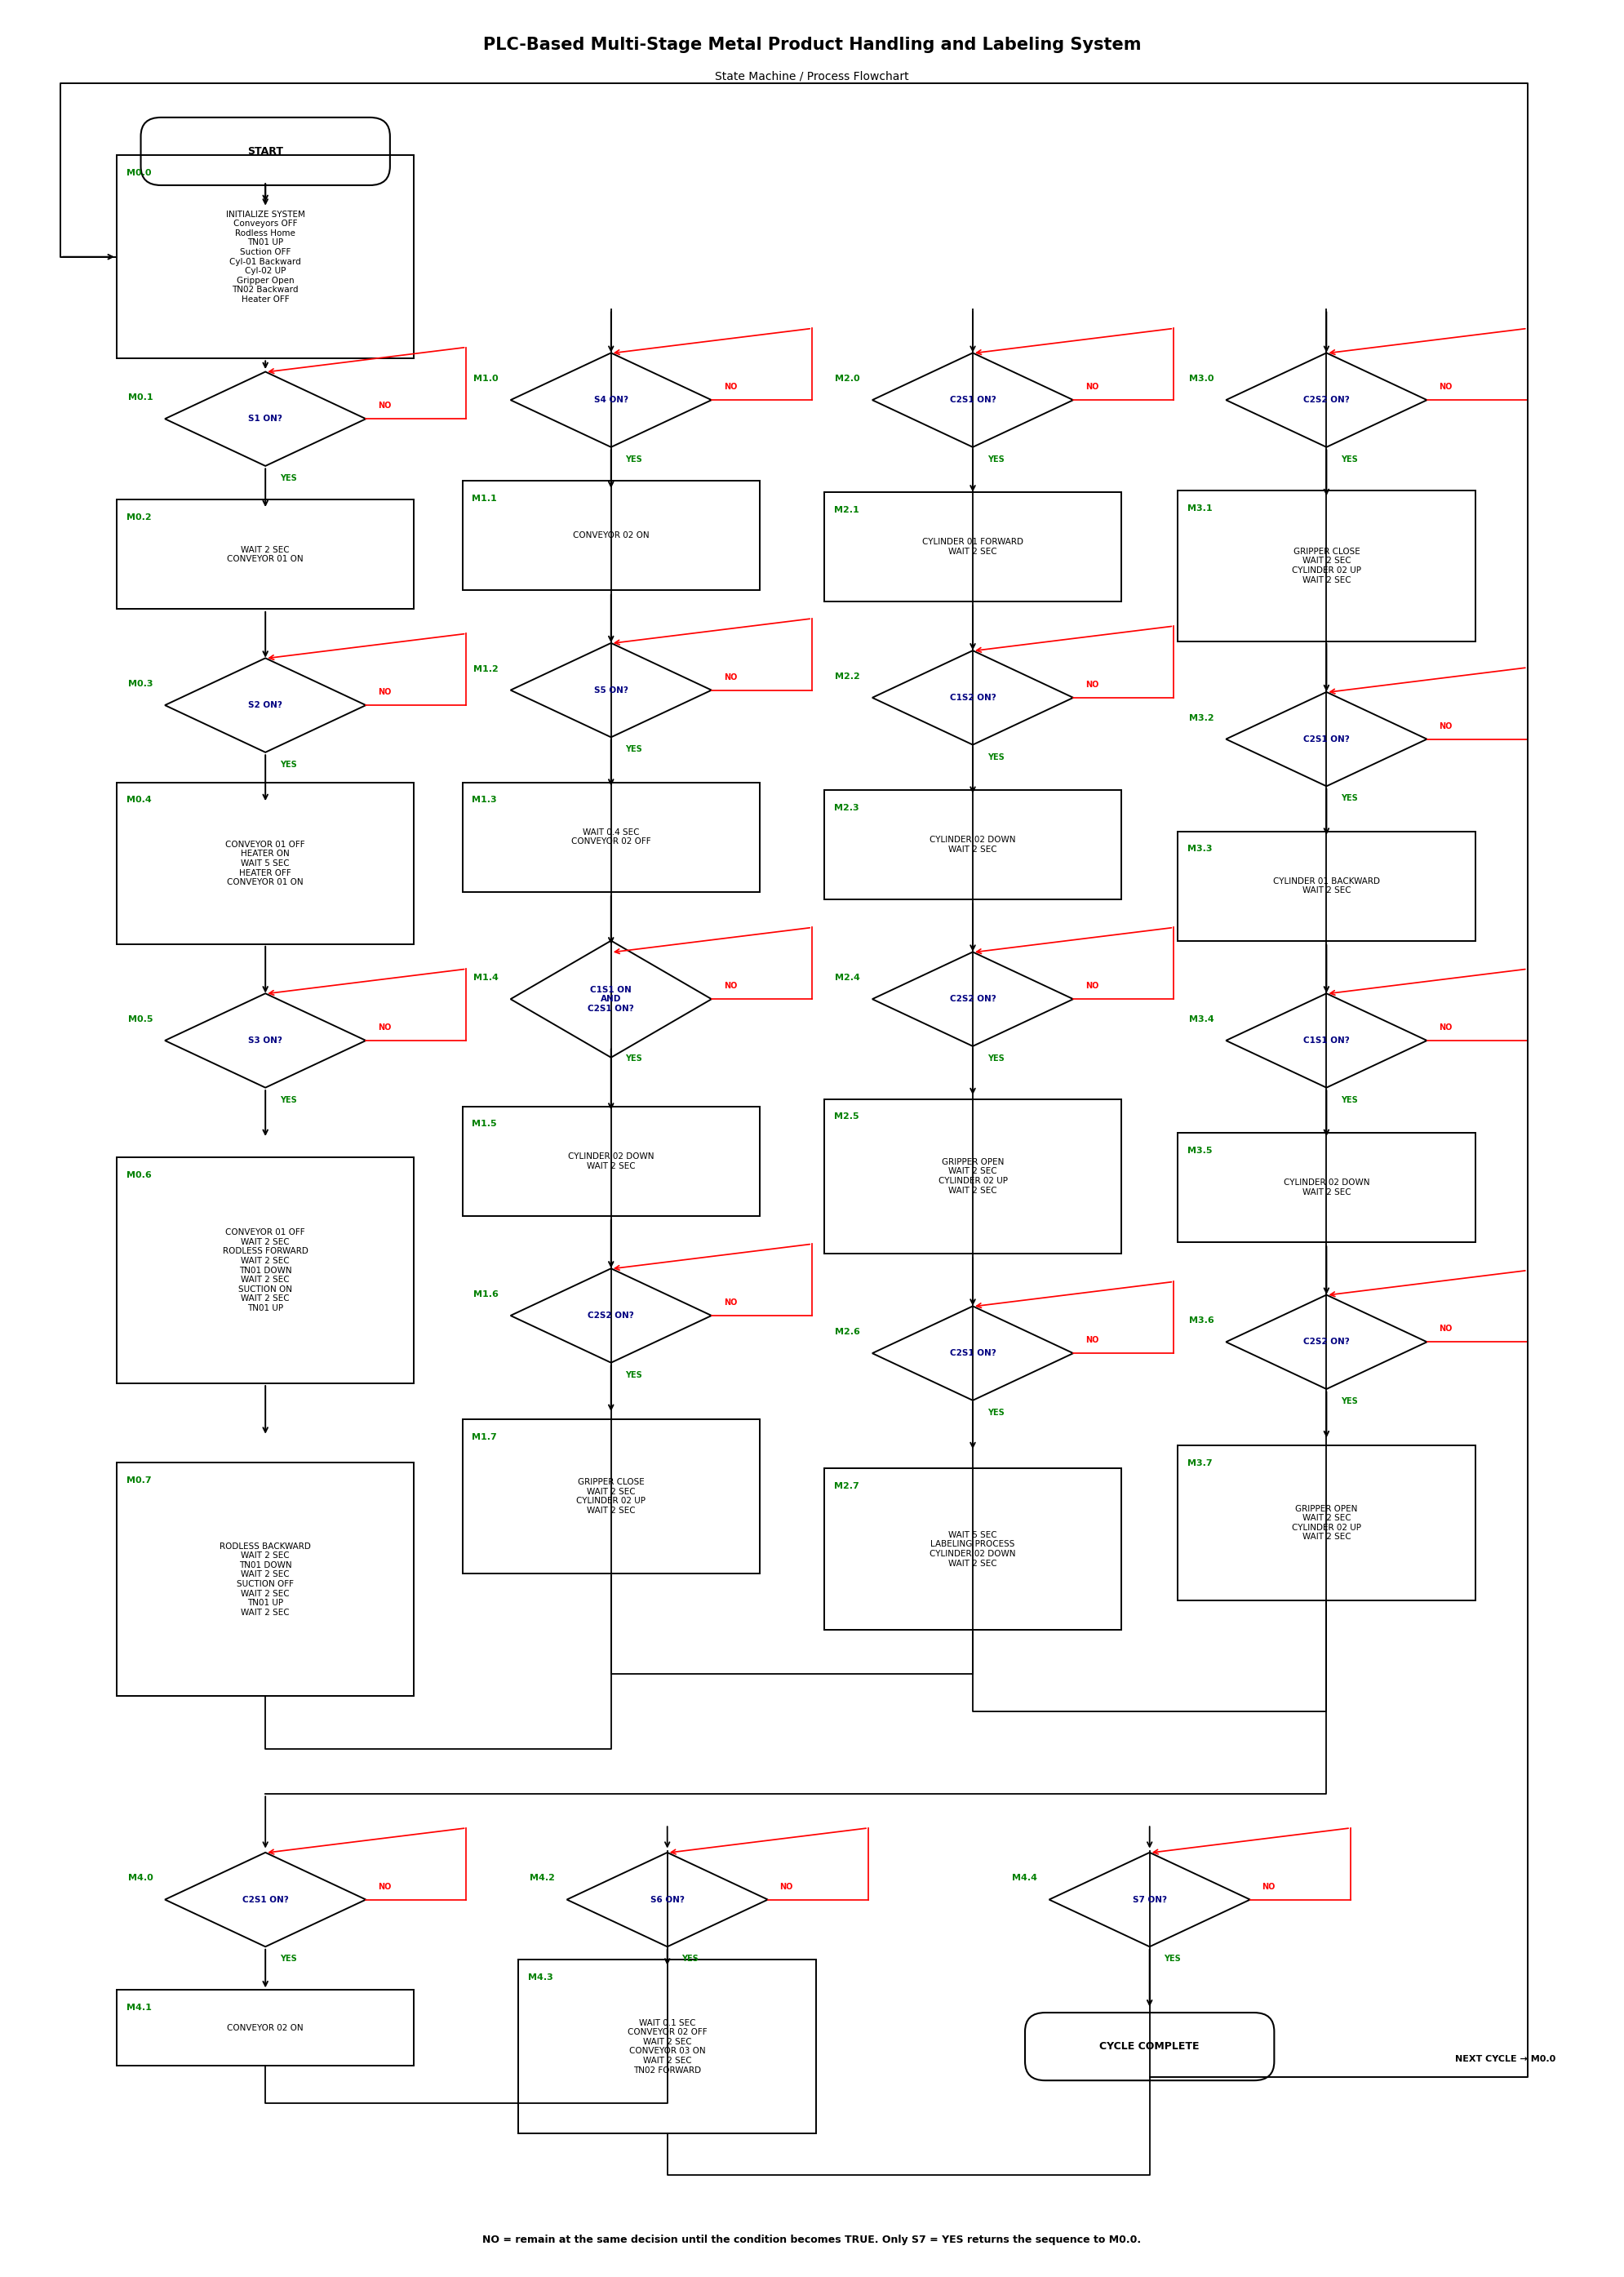

Created:
metal_handling_flowchart_final.png
metal_handling_flowchart_final.pdf


In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon, FancyBboxPatch, Ellipse

# ============================================================
# PLC MULTI-STAGE METAL PRODUCT HANDLING & LABELING SYSTEM
# MANUALLY ROUTED C / SNAKE-SHAPED FLOWCHART
#
# RULES:
# YES -> next state
# NO  -> loop to SAME decision
# S7 YES -> M0.0
# ============================================================

fig, ax = plt.subplots(figsize=(20, 28))

ax.set_xlim(0, 20)
ax.set_ylim(0, 30)
ax.axis("off")

BLACK = "black"
RED = "red"
GREEN = "green"
BLUE = "navy"


# ============================================================
# BASIC SHAPES
# ============================================================

def process_box(x, y, state, text, w=3.7, h=1.45):
    rect = Rectangle(
        (x - w/2, y - h/2),
        w, h,
        fill=False,
        linewidth=1.4,
        edgecolor=BLACK
    )
    ax.add_patch(rect)

    # state label
    ax.text(
        x - w/2 + 0.12,
        y + h/2 - 0.18,
        state,
        fontsize=8,
        fontweight="bold",
        color=GREEN,
        ha="left",
        va="top"
    )

    ax.text(
        x,
        y,
        text,
        fontsize=7.5,
        ha="center",
        va="center"
    )


def decision_box(x, y, state, text, w=2.5, h=1.25):
    pts = [
        (x, y + h/2),
        (x + w/2, y),
        (x, y - h/2),
        (x - w/2, y)
    ]

    poly = Polygon(
        pts,
        closed=True,
        fill=False,
        linewidth=1.4,
        edgecolor=BLACK
    )
    ax.add_patch(poly)

    ax.text(
        x - w/2 - 0.15,
        y + 0.25,
        state,
        fontsize=8,
        fontweight="bold",
        color=GREEN,
        ha="right"
    )

    ax.text(
        x,
        y,
        text,
        fontsize=7.5,
        fontweight="bold",
        color=BLUE,
        ha="center",
        va="center"
    )


def start_end(x, y, text):
    e = FancyBboxPatch(
        (x - 1.5, y - 0.4),
        3.0, 0.8,
        boxstyle="round,pad=0.05,rounding_size=0.25",
        fill=False,
        linewidth=1.5
    )
    ax.add_patch(e)

    ax.text(
        x, y,
        text,
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold"
    )


# ============================================================
# ARROWS
# ============================================================

def arrow_down(x, y1, y2):
    ax.annotate(
        "",
        xy=(x, y2),
        xytext=(x, y1),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.4,
            color=BLACK
        )
    )


def arrow_right(x1, y, x2):
    ax.annotate(
        "",
        xy=(x2, y),
        xytext=(x1, y),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.4,
            color=BLACK
        )
    )


def arrow_left(x1, y, x2):
    ax.annotate(
        "",
        xy=(x2, y),
        xytext=(x1, y),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.4,
            color=BLACK
        )
    )


def no_loop_right(x, y, loop_width=1.25, loop_height=0.95):
    """
    NO exits to the RIGHT and loops back
    into the SAME decision diamond.
    """

    right_edge = x + 1.25

    # exit right
    ax.plot(
        [right_edge, right_edge + loop_width],
        [y, y],
        color=RED,
        linewidth=1.25
    )

    # go upward
    ax.plot(
        [right_edge + loop_width, right_edge + loop_width],
        [y, y + loop_height],
        color=RED,
        linewidth=1.25
    )

    # return left above diamond
    ax.annotate(
        "",
        xy=(x, y + 0.62),
        xytext=(right_edge + loop_width, y + loop_height),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.25,
            color=RED
        )
    )

    ax.text(
        right_edge + 0.15,
        y + 0.14,
        "NO",
        fontsize=7,
        fontweight="bold",
        color=RED
    )


def yes_down(x, y, y_next):
    ax.text(
        x + 0.18,
        y - 0.82,
        "YES",
        fontsize=7,
        fontweight="bold",
        color=GREEN
    )

    arrow_down(
        x,
        y - 0.63,
        y_next
    )


# ============================================================
# TITLE
# ============================================================

ax.text(
    10,
    29.45,
    "PLC-Based Multi-Stage Metal Product Handling and Labeling System",
    fontsize=15,
    fontweight="bold",
    ha="center"
)

ax.text(
    10,
    29.05,
    "State Machine / Process Flowchart",
    fontsize=10,
    ha="center"
)


# ============================================================
# COLUMN 1
# M0.0 -> M0.7
# ============================================================

x1 = 3.2

start_end(
    x1,
    28.1,
    "START"
)

process_box(
    x1,
    26.7,
    "M0.0",
    """INITIALIZE SYSTEM
Conveyors OFF
Rodless Home
TN01 UP
Suction OFF
Cyl-01 Backward
Cyl-02 UP
Gripper Open
TN02 Backward
Heater OFF""",
    h=2.7
)

arrow_down(x1, 27.7, 28.5 - 1.1)
# clean START -> M0.0
arrow_down(x1, 27.7, 27.35)

decision_box(
    x1,
    24.55,
    "M0.1",
    "S1 ON?"
)

arrow_down(x1, 25.35, 25.18)
yes_down(x1, 24.55, 23.35)
no_loop_right(x1, 24.55)

process_box(
    x1,
    22.75,
    "M0.2",
    """WAIT 2 SEC
CONVEYOR 01 ON"""
)

arrow_down(x1, 22.02, 21.35)

decision_box(
    x1,
    20.75,
    "M0.3",
    "S2 ON?"
)

yes_down(x1, 20.75, 19.45)
no_loop_right(x1, 20.75)

process_box(
    x1,
    18.65,
    "M0.4",
    """CONVEYOR 01 OFF
HEATER ON
WAIT 5 SEC
HEATER OFF
CONVEYOR 01 ON""",
    h=2.15
)

arrow_down(x1, 17.58, 16.9)

decision_box(
    x1,
    16.3,
    "M0.5",
    "S3 ON?"
)

yes_down(x1, 16.3, 15.0)
no_loop_right(x1, 16.3)

process_box(
    x1,
    13.25,
    "M0.6",
    """CONVEYOR 01 OFF
WAIT 2 SEC
RODLESS FORWARD
WAIT 2 SEC
TN01 DOWN
WAIT 2 SEC
SUCTION ON
WAIT 2 SEC
TN01 UP""",
    h=3.0
)

arrow_down(x1, 11.75, 11.05)

process_box(
    x1,
    9.15,
    "M0.7",
    """RODLESS BACKWARD
WAIT 2 SEC
TN01 DOWN
WAIT 2 SEC
SUCTION OFF
WAIT 2 SEC
TN01 UP
WAIT 2 SEC""",
    h=3.1
)


# ============================================================
# COLUMN 2
# M1.0 -> M1.7
# ============================================================

x2 = 7.5

# M0.7 -> M1.0
ax.plot(
    [x1, x1, x2, x2],
    [7.60, 6.9, 6.9, 26.0],
    color=BLACK,
    linewidth=1.3
)

ax.annotate(
    "",
    xy=(x2, 25.4),
    xytext=(x2, 26.0),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.3,
        color=BLACK
    )
)

decision_box(
    x2,
    24.8,
    "M1.0",
    "S4 ON?"
)

yes_down(x2, 24.8, 23.6)
no_loop_right(x2, 24.8)

process_box(
    x2,
    23.0,
    "M1.1",
    "CONVEYOR 02 ON"
)

arrow_down(x2, 22.25, 21.55)

decision_box(
    x2,
    20.95,
    "M1.2",
    "S5 ON?"
)

yes_down(x2, 20.95, 19.65)
no_loop_right(x2, 20.95)

process_box(
    x2,
    19.0,
    "M1.3",
    """WAIT 0.4 SEC
CONVEYOR 02 OFF"""
)

arrow_down(x2, 18.25, 17.55)

decision_box(
    x2,
    16.85,
    "M1.4",
    """C1S1 ON
AND
C2S1 ON?""",
    h=1.55
)

yes_down(x2, 16.85, 15.35)
no_loop_right(x2, 16.85)

process_box(
    x2,
    14.7,
    "M1.5",
    """CYLINDER 02 DOWN
WAIT 2 SEC"""
)

arrow_down(x2, 13.95, 13.25)

decision_box(
    x2,
    12.65,
    "M1.6",
    "C2S2 ON?"
)

yes_down(x2, 12.65, 11.35)
no_loop_right(x2, 12.65)

process_box(
    x2,
    10.25,
    "M1.7",
    """GRIPPER CLOSE
WAIT 2 SEC
CYLINDER 02 UP
WAIT 2 SEC""",
    h=2.05
)


# ============================================================
# COLUMN 3
# M2.0 -> M2.7
# ============================================================

x3 = 12.0

# M1.7 -> M2.0
ax.plot(
    [x2, x2, x3, x3],
    [9.20, 7.9, 7.9, 26.0],
    color=BLACK,
    linewidth=1.3
)

ax.annotate(
    "",
    xy=(x3, 25.4),
    xytext=(x3, 26.0),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.3,
        color=BLACK
    )
)

decision_box(
    x3,
    24.8,
    "M2.0",
    "C2S1 ON?"
)

yes_down(x3, 24.8, 23.55)
no_loop_right(x3, 24.8)

process_box(
    x3,
    22.85,
    "M2.1",
    """CYLINDER 01 FORWARD
WAIT 2 SEC"""
)

arrow_down(x3, 22.10, 21.45)

decision_box(
    x3,
    20.85,
    "M2.2",
    "C1S2 ON?"
)

yes_down(x3, 20.85, 19.55)
no_loop_right(x3, 20.85)

process_box(
    x3,
    18.9,
    "M2.3",
    """CYLINDER 02 DOWN
WAIT 2 SEC"""
)

arrow_down(x3, 18.15, 17.45)

decision_box(
    x3,
    16.85,
    "M2.4",
    "C2S2 ON?"
)

yes_down(x3, 16.85, 15.55)
no_loop_right(x3, 16.85)

process_box(
    x3,
    14.5,
    "M2.5",
    """GRIPPER OPEN
WAIT 2 SEC
CYLINDER 02 UP
WAIT 2 SEC""",
    h=2.05
)

arrow_down(x3, 13.45, 12.75)

decision_box(
    x3,
    12.15,
    "M2.6",
    "C2S1 ON?"
)

yes_down(x3, 12.15, 10.85)
no_loop_right(x3, 12.15)

process_box(
    x3,
    9.55,
    "M2.7",
    """WAIT 5 SEC
LABELING PROCESS
CYLINDER 02 DOWN
WAIT 2 SEC""",
    h=2.15
)


# ============================================================
# COLUMN 4
# M3.0 -> M3.7
# ============================================================

x4 = 16.4

ax.plot(
    [x3, x3, x4, x4],
    [8.45, 7.4, 7.4, 26.0],
    color=BLACK,
    linewidth=1.3
)

ax.annotate(
    "",
    xy=(x4, 25.4),
    xytext=(x4, 26.0),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.3,
        color=BLACK
    )
)

decision_box(
    x4,
    24.8,
    "M3.0",
    "C2S2 ON?"
)

yes_down(x4, 24.8, 23.5)
no_loop_right(x4, 24.8)

process_box(
    x4,
    22.6,
    "M3.1",
    """GRIPPER CLOSE
WAIT 2 SEC
CYLINDER 02 UP
WAIT 2 SEC""",
    h=2.0
)

arrow_down(x4, 21.6, 20.9)

decision_box(
    x4,
    20.3,
    "M3.2",
    "C2S1 ON?"
)

yes_down(x4, 20.3, 19.0)
no_loop_right(x4, 20.3)

process_box(
    x4,
    18.35,
    "M3.3",
    """CYLINDER 01 BACKWARD
WAIT 2 SEC"""
)

arrow_down(x4, 17.60, 16.9)

decision_box(
    x4,
    16.3,
    "M3.4",
    "C1S1 ON?"
)

yes_down(x4, 16.3, 15.0)
no_loop_right(x4, 16.3)

process_box(
    x4,
    14.35,
    "M3.5",
    """CYLINDER 02 DOWN
WAIT 2 SEC"""
)

arrow_down(x4, 13.60, 12.9)

decision_box(
    x4,
    12.3,
    "M3.6",
    "C2S2 ON?"
)

yes_down(x4, 12.3, 11.0)
no_loop_right(x4, 12.3)

process_box(
    x4,
    9.9,
    "M3.7",
    """GRIPPER OPEN
WAIT 2 SEC
CYLINDER 02 UP
WAIT 2 SEC""",
    h=2.05
)


# ============================================================
# BOTTOM C-SHAPE
# M4.0 -> M4.4
# ============================================================

# M3.7 -> M4.0
ax.plot(
    [x4, x4, 3.2],
    [8.85, 6.3, 6.3],
    color=BLACK,
    linewidth=1.3
)

ax.annotate(
    "",
    xy=(3.2, 5.55),
    xytext=(3.2, 6.3),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.3,
        color=BLACK
    )
)

decision_box(
    3.2,
    4.9,
    "M4.0",
    "C2S1 ON?"
)

no_loop_right(3.2, 4.9)

process_box(
    3.2,
    3.2,
    "M4.1",
    "CONVEYOR 02 ON",
    h=1.0
)

yes_down(3.2, 4.9, 3.7)

# M4.1 -> M4.2
ax.plot(
    [3.2, 3.2, 8.2, 8.2],
    [2.7, 2.2, 2.2, 5.55],
    color=BLACK,
    linewidth=1.3
)

ax.annotate(
    "",
    xy=(8.2, 5.55),
    xytext=(8.2, 5.9),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.3,
        color=BLACK
    )
)

decision_box(
    8.2,
    4.9,
    "M4.2",
    "S6 ON?"
)

no_loop_right(8.2, 4.9)

process_box(
    8.2,
    2.95,
    "M4.3",
    """WAIT 0.1 SEC
CONVEYOR 02 OFF
WAIT 2 SEC
CONVEYOR 03 ON
WAIT 2 SEC
TN02 FORWARD""",
    h=2.3
)

yes_down(8.2, 4.9, 4.0)


# M4.3 -> M4.4
ax.plot(
    [8.2, 8.2, 14.2, 14.2],
    [1.8, 1.25, 1.25, 5.55],
    color=BLACK,
    linewidth=1.3
)

ax.annotate(
    "",
    xy=(14.2, 5.55),
    xytext=(14.2, 5.9),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.3,
        color=BLACK
    )
)

decision_box(
    14.2,
    4.9,
    "M4.4",
    "S7 ON?"
)

no_loop_right(
    14.2,
    4.9
)

start_end(
    14.2,
    2.95,
    "CYCLE COMPLETE"
)

yes_down(
    14.2,
    4.9,
    3.45
)


# ============================================================
# M4.4 YES -> M0.0
# ONLY TRUE GLOBAL RETURN PATH
# ============================================================

ax.plot(
    [14.2, 18.9, 18.9, 0.65, 0.65, 1.35],
    [2.55, 2.55, 29.0, 29.0, 26.7, 26.7],
    color=BLACK,
    linewidth=1.4
)

ax.annotate(
    "",
    xy=(1.35, 26.7),
    xytext=(0.65, 26.7),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.4,
        color=BLACK
    )
)

ax.text(
    18.0,
    2.75,
    "NEXT CYCLE → M0.0",
    fontsize=8,
    fontweight="bold"
)


# ============================================================
# NOTES
# ============================================================

ax.text(
    10,
    0.35,
    "NO = remain at the same decision until the condition becomes TRUE. "
    "Only S7 = YES returns the sequence to M0.0.",
    ha="center",
    fontsize=9,
    fontweight="bold"
)


# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

plt.savefig(
    "metal_handling_flowchart_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    "metal_handling_flowchart_final.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Created:")
print("metal_handling_flowchart_final.png")
print("metal_handling_flowchart_final.pdf")